<a href="https://colab.research.google.com/github/ShivamDagur/automotive-machine-breakdown-prediction/blob/main/automotive_machine_breakdown_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("predictive_maintenance.csv")

print(df.head())

print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

# Remove Unnecessary Columns
df = df.drop(["UDI", "Product ID"], axis=1)


print("\nData Types:")
print(df.dtypes)

df["Type"] = df["Type"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

print("\nUnique Type Values:")
print(df["Type"].unique())

# Check Outliers Summary
print("\nStatistical Summary:")
print(df.describe())

# Final Shape
print("\nFinal Dataset Shape:")
print(df.shape)

# Save Cleaned Dataset
df.to_csv("cleaned_predictive_maintenance.csv", index=False)

print("\nData Cleaning Completed Successfully!")

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (tota

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Shape: (10000, 8)

Columns:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')

Summary Statistics:
               Type  Air temperature [K]  Process temperature [K]  \
count  10000.000000         10000.000000             10000.000000   
mean       0.500300           300.004930               310.005560   
std        0.671301             2.000259                 1.483734   
min        0.000000           295.300000               305.700000   
25%        0.000000           298.300000               308.800000   
50%        0.000000           300.100000               310.100000   
75%        1.000000           301.500000               311.100000   
max        2.000000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]        Target  
count            10000.000000  10000.000000     10000.000000  10

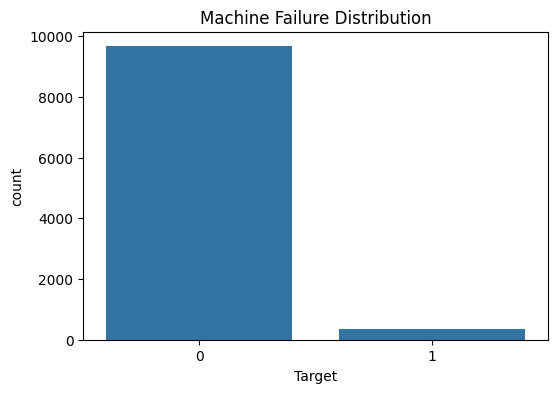

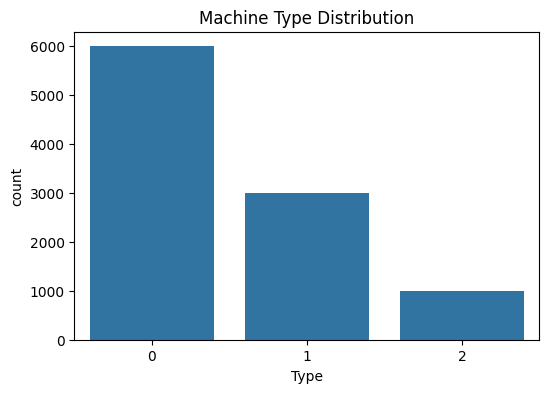

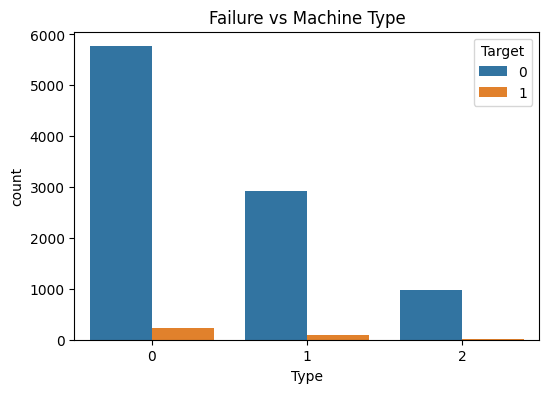

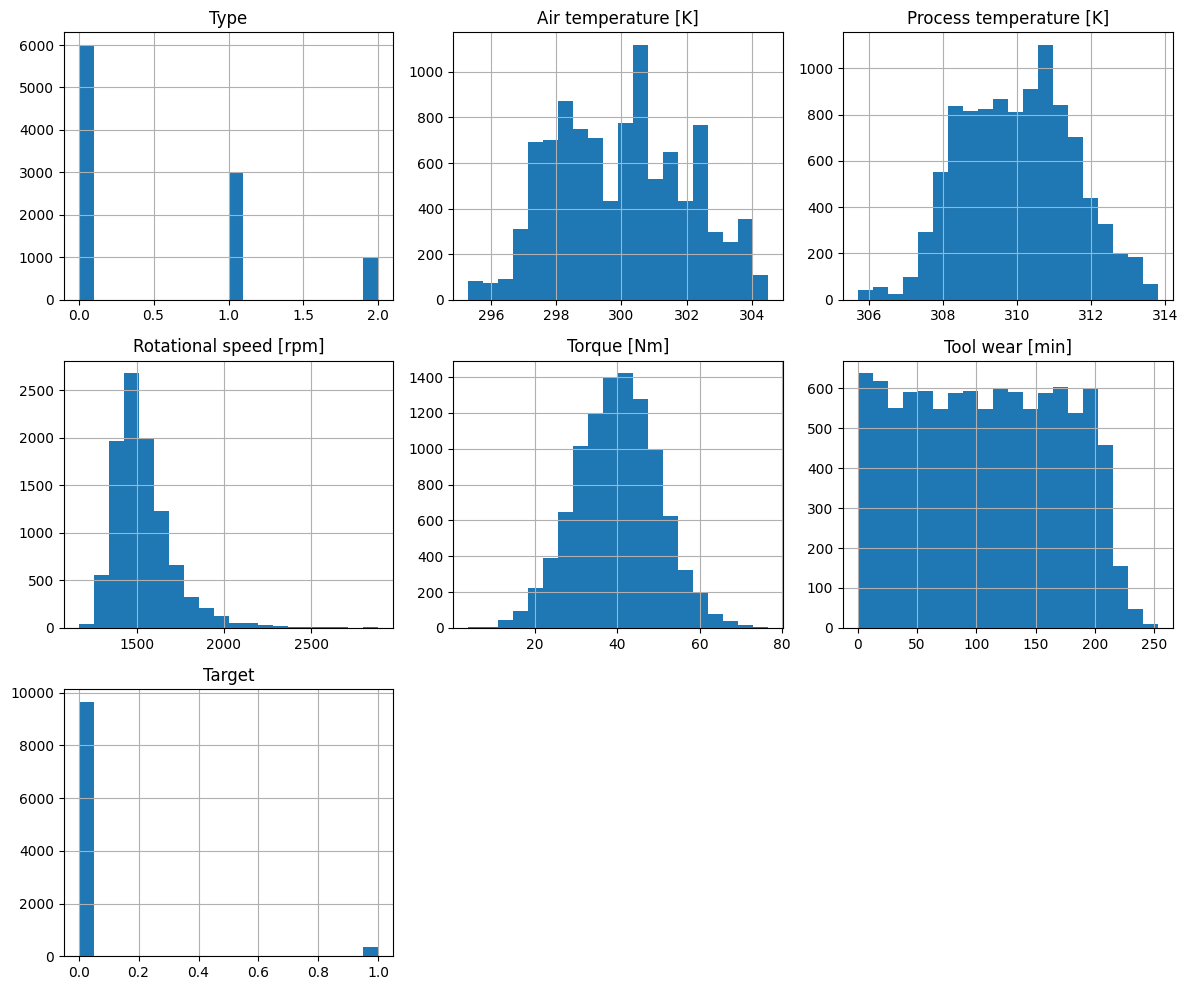

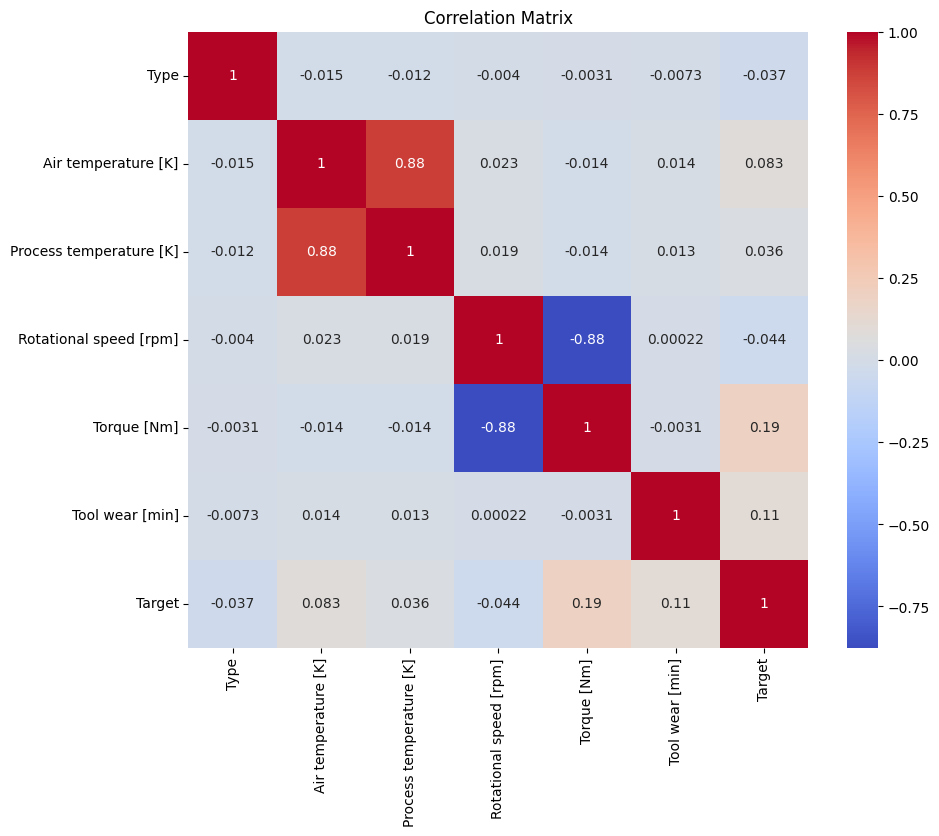

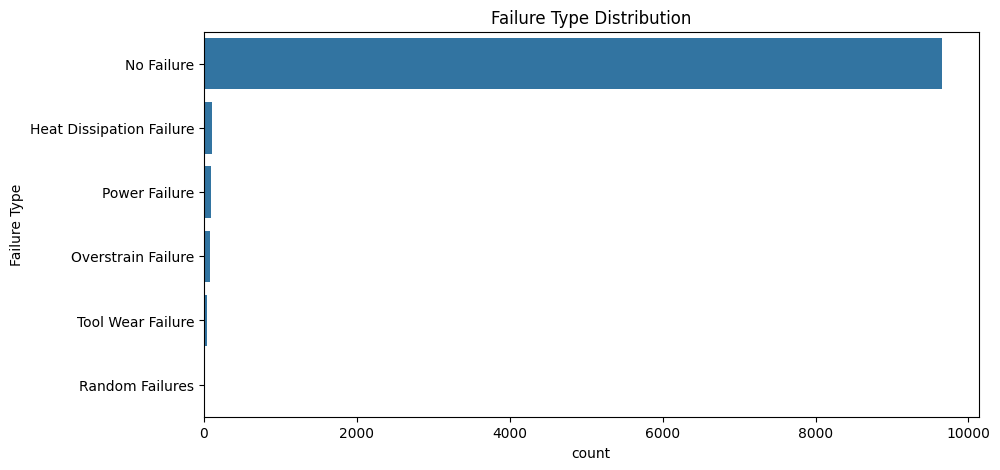


Failure Percentage: 3.39%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_predictive_maintenance.csv")

# Basic Information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nSummary Statistics:")
print(df.describe())

# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title("Machine Failure Distribution")
plt.show()

# Machine Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title("Machine Type Distribution")
plt.show()

# Failure by Machine Type
plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Target', data=df)
plt.title("Failure vs Machine Type")
plt.show()

# Numerical Feature Histograms
df.hist(
    figsize=(12,10),
    bins=20
)
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()



# Failure Type Analysis
plt.figure(figsize=(10,5))
sns.countplot(
    y='Failure Type',
    data=df,
    order=df['Failure Type'].value_counts().index
)
plt.title("Failure Type Distribution")
plt.show()


# Failure Percentage
failure_rate = df['Target'].mean()*100
print(f"\nFailure Percentage: {failure_rate:.2f}%")

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_predictive_maintenance.csv")

X = df.drop(["Target", "Failure Type"], axis=1)
y = df["Target"]

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Decision Tree Train karo
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9785


In [ ]:
# Random Forest Train karo
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9845


In [ ]:
# Model Evaluation
from sklearn.metrics import classification_report

print("\nDecision Tree Report")
print(classification_report(y_test, y_pred_dt))

print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf))


Decision Tree Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.75      0.44      0.56        61

    accuracy                           0.98      2000
   macro avg       0.87      0.72      0.77      2000
weighted avg       0.98      0.98      0.98      2000


Random Forest Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.59      0.70        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



                   Feature  Importance
4              Torque [Nm]    0.302840
3   Rotational speed [rpm]    0.238668
5          Tool wear [min]    0.158054
1      Air temperature [K]    0.140315
2  Process temperature [K]    0.132750
0                     Type    0.027373


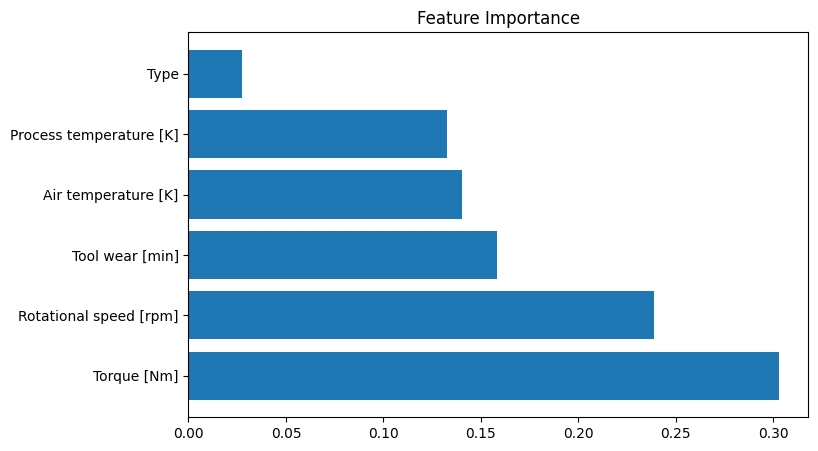

In [ ]:
# Feature Importance (Project ke liye important)
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =====================
# Meta Model
# Linear Regression Stacking
# =====================

dt_train_pred = dt.predict(X_train)
rf_train_pred = rf.predict(X_train)

X_meta_train = np.column_stack(
    (dt_train_pred, rf_train_pred)
)

meta = LinearRegression()

meta.fit(X_meta_train, y_train)

# Test Data

dt_test_pred = dt.predict(X_test)
rf_test_pred = rf.predict(X_test)

X_meta_test = np.column_stack(
    (dt_test_pred, rf_test_pred)
)

meta_pred = meta.predict(X_meta_test)

final_pred = (
    meta_pred >= 0.5
).astype(int)


In [ ]:
# =====================
# Comparison Table
# =====================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Decision Tree":[
        accuracy_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_dt)
    ],

    "Random Forest":[
        accuracy_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_rf)
    ],

    "Meta Model":[
        accuracy_score(y_test,final_pred),
        precision_score(y_test,final_pred),
        recall_score(y_test,final_pred),
        f1_score(y_test,final_pred)
    ]

})

print("\nMODEL COMPARISON\n")
print(comparison)

# =====================
# Meta Model Weights
# =====================

dt_train_prob = dt.predict_proba(X_train)[:,1]
rf_train_prob = rf.predict_proba(X_train)[:,1]

X_meta_train = np.column_stack(
    (dt_train_prob, rf_train_prob)
)

meta.fit(X_meta_train, y_train)

dt_test_prob = dt.predict_proba(X_test)[:,1]
rf_test_prob = rf.predict_proba(X_test)[:,1]

X_meta_test = np.column_stack(
    (dt_test_prob, rf_test_prob)
)

meta_pred = meta.predict(X_meta_test)

weights = abs(meta.coef_)
weights = weights / weights.sum()
print()

print("Weighted Vector" , weights)





MODEL COMPARISON

      Metric  Decision Tree  Random Forest  Meta Model
0   Accuracy       0.978500       0.984500    0.984500
1  Precision       0.750000       0.857143    0.857143
2     Recall       0.442623       0.590164    0.590164
3   F1 Score       0.556701       0.699029    0.699029

Weighted Vector [0.12748461 0.87251539]
